# 04 · คำถามข้อ 4: ประเภทเนื้อหาที่เสพ

เทียบคะแนนสามมิติระหว่าง 4 กลุ่มเนื้อหา (ข่าว บันเทิง ชีวิตประจำวันของคนอื่น และอื่น ๆ)
ใช้ Kruskal-Wallis ซึ่งเทียบอันดับแทนค่าเฉลี่ย เพราะกลุ่มมีขนาดต่างกันมากและคะแนน DASS-21 เบ้ขวา
กล่องในกราฟคือควอร์ไทล์ที่ 1 ถึง 3 เส้นกลางกล่องคือมัธยฐาน

In [1]:
import os
import pathlib
import sys

# notebook.nvim starts the kernel in nvim's cwd; step into codingpy/ so common.py
# and data/ are found when the notebook is opened from the repo root
if pathlib.Path("codingpy/common.py").is_file():
    os.chdir("codingpy")
    sys.path.insert(0, os.getcwd())

%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

from common import DIMENSIONS, FIG_DIR, THAI_FONT, load_data, passed_attention

df = passed_attention(load_data())  # the sample every research question uses
print(f"{len(df)} respondents passed the attention check")

107 respondents passed the attention check


Depression: Kruskal-Wallis H = 0.418, p = 0.9364
Anxiety: Kruskal-Wallis H = 0.659, p = 0.8828
Stress: Kruskal-Wallis H = 1.460, p = 0.6914


Saved: ../figures/q4-content-type.png


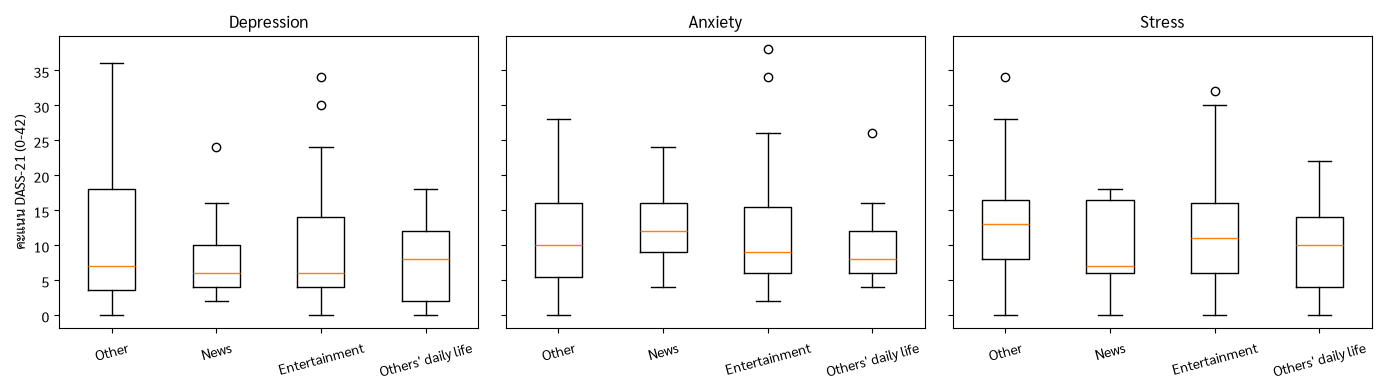

In [3]:
GROUP_COL = "content_group"
CONTENT_FIG_PATH = FIG_DIR / "q4-content-type.png"


def content_type_tests(df: pd.DataFrame) -> None:
    for col, name in DIMENSIONS.items():
        groups = [group[col].dropna() for _, group in df.groupby(GROUP_COL)]
        # ใช้ Kruskal-Wallis ตามที่ระบุในคู่มือโครงงาน
        stat, p = stats.kruskal(*groups)
        print(f"{name}: Kruskal-Wallis H = {stat:.3f}, p = {p:.4f}")


def content_type_plot(df: pd.DataFrame) -> None:
    plt.rcParams["font.family"] = THAI_FONT
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

    # จัดเรียงประเภทกลุ่มเนื้อหา
    group_order = df[GROUP_COL].dropna().unique()

    for ax, (col, name) in zip(axes, DIMENSIONS.items()):
        data_to_plot = [df[df[GROUP_COL] == g][col].dropna() for g in group_order]
        ax.boxplot(data_to_plot, tick_labels=group_order)
        ax.set_title(name)
        ax.tick_params(axis='x', rotation=15)

    axes[0].set_ylabel("คะแนน DASS-21 (0-42)")
    fig.tight_layout()
    fig.savefig(CONTENT_FIG_PATH, dpi=200, facecolor="white")
    print(f"Saved: {CONTENT_FIG_PATH}")
    plt.show()


content_type_tests(df)
content_type_plot(df)

**อ่านผล** ไม่พบความแตกต่างระหว่างกลุ่มเนื้อหาในมิติใดเลย (p = 0.936, 0.883 และ 0.691)
กล่องของทั้งสี่กลุ่มซ้อนทับกันในทุกมิติ
ข้อควรระวังคือกลุ่มข่าวมีเพียง 8 คน และกลุ่มชีวิตประจำวันของคนอื่น 13 คน การทดสอบจึงมีกำลังต่ำที่จะจับความต่างขนาดเล็ก